# ECG RetNet v4 — Google Colab Training
**Dataset:** Google Drive → `ptbxl_sota_100hz_diagnostic_superclass.npz`  
**Model:** RetNet-ECG v4 (Цель: 96+ Macro AUROC)

| Улучшение | v3 | v4 |
|---|---|---|
| d_model | 384 | **512** (+33%) |
| n_blocks | 10 | 10 |
| num_heads | 6 | **8** |
| Patch Embed | 2-layer conv k=5 | **Multi-scale k=5/11/25** (inception) |
| Lead fusion | mean | **Lead Fusion Transformer** (2-layer cross-lead attn) |
| Stochastic depth | — | **DropPath rate=0.1** |
| EMA | — | **EMA decay=0.9999** |
| CutMix | — | **ECG CutMix p=0.5** |
| Augmentations | 5 types | **+freq_dropout, +amplitude_flip** |
| Epochs | 70 | **100** |
| LR / WD | 1e-3 / 0.01 | **3e-4 / 0.05** |
| Grad accum | 1 | **2** (eff. batch=64) |
| TTA passes | 10 | **15** |

In [1]:
# ── Cell 1: Mount Drive & Check GPU ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'GPU {i}: {torch.cuda.get_device_name(i)}')
        print(f'  Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB')


Mounted at /content/drive
PyTorch: 2.10.0+cu128
CUDA available: True
GPU 0: NVIDIA A100-SXM4-40GB
  Memory: 42.4 GB


In [2]:
# ── Cell 2: Verify Data ───────────────────────────────────────
import numpy as np
from pathlib import Path
import os

DATA_PATH = Path('/content/drive/MyDrive/train_d/ecg-diploma/data_preprocessed/ptbxl_sota_100hz_diagnostic_superclass.npz')

assert DATA_PATH.exists(), f'File not found: {DATA_PATH}'

data = np.load(DATA_PATH, allow_pickle=True)
print('Keys:', list(data.keys()))
for k in data.keys():
    arr = data[k]
    if hasattr(arr, 'shape'):
        print(f'  {k}: shape={arr.shape}, dtype={arr.dtype}')
    else:
        print(f'  {k}: {arr}')


Keys: ['signals', 'labels', 'splits', 'ecg_ids', 'class_names', 'sampling_rate']
  signals: shape=(21799, 12, 1000), dtype=float32
  labels: shape=(21799, 5), dtype=float64
  splits: shape=(21799,), dtype=<U5
  ecg_ids: shape=(21799,), dtype=int64
  class_names: shape=(5,), dtype=<U4
  sampling_rate: shape=(), dtype=int64


In [3]:
# ── Cell 3: Dataset & DataLoaders ────────────────────────────
import random
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f'Seed set: {seed}')


class ECGAugmentation:
    @staticmethod
    def add_gaussian_noise(signal, std=0.02):
        return signal + torch.randn_like(signal) * std

    @staticmethod
    def scale_amplitude(signal, scale_range=(0.80, 1.20)):
        scale = torch.empty(1).uniform_(*scale_range).item()
        return signal * scale

    @staticmethod
    def time_shift(signal, max_shift=50):
        shift = torch.randint(-max_shift, max_shift + 1, (1,)).item()
        return torch.roll(signal, shifts=shift, dims=-1)

    @staticmethod
    def baseline_wander(signal, max_amp=0.15, max_freq=0.5):
        """Имитирует дрейф изолинии."""
        L = signal.shape[-1]
        t = torch.linspace(0, 1, L, device=signal.device, dtype=signal.dtype)
        freq = random.uniform(0.05, max_freq)
        phase = random.uniform(0, 2 * np.pi)
        amp = random.uniform(0, max_amp)
        wander = amp * torch.sin(2 * np.pi * freq * t + phase)
        return signal + wander.unsqueeze(0)

    @staticmethod
    def channel_dropout(signal, p=0.10):
        """Случайно зануляет один лид — плохой контакт электрода."""
        if random.random() < p:
            ch = random.randint(0, signal.shape[0] - 1)
            signal = signal.clone()
            signal[ch] = 0.0
        return signal

    @staticmethod
    def frequency_dropout(signal, band_drop_prob=0.25):
        """[NEW v4] Случайно зануляет полосу частот в FFT спектре.
        Имитирует мышечные артефакты или наводки сети 50/60 Гц."""
        if random.random() < band_drop_prob:
            fft = torch.fft.rfft(signal, dim=-1)
            L = fft.shape[-1]
            band_start = random.randint(0, max(1, L // 2))
            band_width = random.randint(1, max(1, L // 8))
            fft[..., band_start:band_start + band_width] = 0
            signal = torch.fft.irfft(fft, n=signal.shape[-1], dim=-1)
        return signal

    @staticmethod
    def amplitude_flip(signal, p=0.1):
        """[NEW v4] Инвертирует амплитуду случайного лида.
        Имитирует переполюсовку электрода — реальный клинический сценарий."""
        if random.random() < p:
            ch = random.randint(0, signal.shape[0] - 1)
            signal = signal.clone()
            signal[ch] = -signal[ch]
        return signal


class RandomApplyList:
    def __init__(self, transforms, p=0.5):
        self.transforms = transforms
        self.p = p

    def __call__(self, signal):
        for t in self.transforms:
            if random.random() < self.p:
                signal = t(signal)
        return signal


class PTBXLDataset(Dataset):
    def __init__(self, data_path, split='train', augment=False, seed=42):
        data = np.load(data_path, allow_pickle=True)
        all_signals = data['signals'].astype(np.float32)
        all_labels  = data['labels'].astype(np.float32)
        all_splits  = data['splits']

        idx = np.where(all_splits == split)[0]
        self.signals     = all_signals[idx]
        self.labels      = all_labels[idx]
        self.class_names = list(data['class_names']) if 'class_names' in data \
                           else ['NORM', 'MI', 'STTC', 'CD', 'HYP']

        self.transform = RandomApplyList([
            ECGAugmentation.add_gaussian_noise,
            ECGAugmentation.scale_amplitude,
            ECGAugmentation.time_shift,
            ECGAugmentation.baseline_wander,
            ECGAugmentation.channel_dropout,
            ECGAugmentation.frequency_dropout,   # NEW v4
            ECGAugmentation.amplitude_flip,      # NEW v4
        ], p=0.5) if augment else None

        print(f'[OK] Loaded {split}: {len(self)} samples, shape={self.signals[0].shape}')

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        signal = torch.from_numpy(self.signals[idx])
        label  = torch.from_numpy(self.labels[idx])
        if self.transform:
            signal = self.transform(signal)
        return signal, label

    def get_class_weights(self):
        pos = self.labels.sum(axis=0)
        neg = len(self.labels) - pos
        return torch.tensor(neg / np.maximum(pos, 1), dtype=torch.float32)


def get_dataloaders(data_path, batch_size=32, num_workers=4, seed=42):
    set_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)

    train_ds = PTBXLDataset(data_path, 'train', augment=True,  seed=seed)
    val_ds   = PTBXLDataset(data_path, 'val',   augment=False, seed=seed)
    test_ds  = PTBXLDataset(data_path, 'test',  augment=False, seed=seed)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True,
                              drop_last=True, generator=g)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')
    return train_loader, val_loader, test_loader


In [4]:
# ── Cell 4: RetNet Model v4 ──────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ── Drop Path (Stochastic Depth) ──────────────────────────────
class DropPath(nn.Module):
    """[NEW v4] Stochastic depth: randomly drops entire residual path.
    Доказано улучшает обобщение у глубоких сетей (+0.2-0.5% AUROC).
    Во время инференса автоматически отключается.
    Источник: https://arxiv.org/abs/1603.09382
    """
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep_prob = 1.0 - self.drop_prob
        # shape: (batch, 1, 1, ...) для broadcast
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.bernoulli(
            torch.full(shape, keep_prob, device=x.device, dtype=x.dtype)
        ) / keep_prob
        return x * mask


# ── Multi-Scale Retention ─────────────────────────────────────
class MultiScaleRetention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model   = d_model
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads

        gammas = 1.0 - 2.0 ** (
            -(5 + torch.arange(num_heads, dtype=torch.float32) * 3.0 / num_heads)
        )
        self.register_buffer('gammas', gammas)

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_G = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.group_norm = nn.GroupNorm(num_heads, d_model)

        freq = torch.arange(0, self.head_dim, 2, dtype=torch.float32)
        freq = 1.0 / (10000 ** (freq / self.head_dim))
        self.register_buffer('freq', freq)

    def _build_decay_mask(self, T, device):
        idx  = torch.arange(T, device=device, dtype=torch.float32)
        diff = idx.unsqueeze(1) - idx.unsqueeze(0)
        mask = (diff >= 0).float()
        D = self.gammas.view(-1, 1, 1) ** diff.unsqueeze(0) * mask.unsqueeze(0)
        return D

    def _apply_xpos(self, x, T):
        pos   = torch.arange(T, device=x.device, dtype=x.dtype).unsqueeze(1)
        freq  = self.freq.to(x.dtype)
        angles = pos * freq
        cos_a = angles.cos().unsqueeze(0).unsqueeze(2)
        sin_a = angles.sin().unsqueeze(0).unsqueeze(2)
        x1 = x[..., ::2]
        x2 = x[..., 1::2]
        x_rot = torch.stack([x1 * cos_a - x2 * sin_a,
                              x1 * sin_a + x2 * cos_a], dim=-1)
        return x_rot.flatten(-2)

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.num_heads, self.head_dim

        Q = self.W_Q(x).view(B, T, H, D)
        K = self.W_K(x).view(B, T, H, D)
        V = self.W_V(x).view(B, T, H, D)
        G = F.silu(self.W_G(x))

        Q = self._apply_xpos(Q, T)
        K = self._apply_xpos(K, T)

        Q = Q.permute(0, 2, 1, 3)
        K = K.permute(0, 2, 1, 3)
        V = V.permute(0, 2, 1, 3)

        scale  = D ** -0.5
        attn   = torch.matmul(Q, K.transpose(-2, -1)) * scale
        D_mask = self._build_decay_mask(T, x.device)
        attn   = attn * D_mask.unsqueeze(0)
        denom  = D_mask.sum(dim=-1, keepdim=True).unsqueeze(0).clamp(min=1e-6)
        attn   = attn / denom

        out = torch.matmul(attn, V)
        out = out.permute(0, 2, 1, 3).reshape(B, T, C)
        out = self.group_norm(out.transpose(1, 2)).transpose(1, 2)
        out = out * G
        return self.W_O(out)


class RetNetFFN(nn.Module):
    def __init__(self, d_model, ffn_mult=2):
        super().__init__()
        d_ff = int(d_model * ffn_mult)
        self.W1 = nn.Linear(d_model, d_ff * 2, bias=False)
        self.W2 = nn.Linear(d_ff, d_model, bias=False)

    def forward(self, x):
        ab = self.W1(x)
        a, b = ab.chunk(2, dim=-1)
        return self.W2(F.silu(a) * b)


class RetNetBlock(nn.Module):
    """[UPDATED v4] Добавлен DropPath для stochastic depth."""
    def __init__(self, d_model, num_heads, ffn_mult=2, drop_path=0.0):
        super().__init__()
        self.ln1       = nn.LayerNorm(d_model)
        self.retention = MultiScaleRetention(d_model, num_heads)
        self.ln2       = nn.LayerNorm(d_model)
        self.ffn       = RetNetFFN(d_model, ffn_mult)
        self.drop_path = DropPath(drop_path)

    def forward(self, x):
        x = x + self.drop_path(self.retention(self.ln1(x)))
        x = x + self.drop_path(self.ffn(self.ln2(x)))
        return x


# ── [NEW v4] Multi-Scale Patch Embedding ─────────────────────
class MultiScalePatchEmbed(nn.Module):
    """Inception-style патч-эмбеддинг с тремя параллельными ядрами.

    k=5  (stride=5) → 200 токенов — детали морфологии (QRS спайки, зазубрины)
    k=11 (stride=5) → 200 токенов — огибающая QRS комплекса
    k=25 (stride=5) → 200 токенов — волны P/T, медленные осцилляции

    Три ветки конкатенируются по каналам, затем 1×1 Conv → d_model.
    Одна и та же архитектура для каждого лида (применяется к B*12 последовательностям).

    Мотивация: разные клинически значимые паттерны ЭКГ существуют
    на разных временных масштабах. Один патч-размер не покрывает всё.
    """
    def __init__(self, d_model=512, stride=5):
        super().__init__()
        d  = d_model // 3
        d3 = d_model - 2 * d   # остаток (для точного d_model)
        # kernel=5,  pad=0  → output = (1000-5)/5+1 = 200
        # kernel=11, pad=3  → output = (1000+6-11)/5+1 = 200
        # kernel=25, pad=10 → output = (1000+20-25)/5+1 = 200
        self.branch1 = nn.Sequential(
            nn.Conv1d(1, d,  kernel_size=5,  stride=stride, padding=0,  bias=False),
            nn.GELU(),
        )
        self.branch2 = nn.Sequential(
            nn.Conv1d(1, d,  kernel_size=11, stride=stride, padding=3,  bias=False),
            nn.GELU(),
        )
        self.branch3 = nn.Sequential(
            nn.Conv1d(1, d3, kernel_size=25, stride=stride, padding=10, bias=False),
            nn.GELU(),
        )
        self.proj = nn.Conv1d(d_model, d_model, kernel_size=1, bias=False)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B*n_leads, 1, L)
        b1 = self.branch1(x)   # (B*n_leads, d,  T)
        b2 = self.branch2(x)   # (B*n_leads, d,  T)
        b3 = self.branch3(x)   # (B*n_leads, d3, T)
        T  = min(b1.shape[-1], b2.shape[-1], b3.shape[-1])  # выравниваем
        out = torch.cat([b1[..., :T], b2[..., :T], b3[..., :T]], dim=1)  # (B*n_leads, d_model, T)
        out = self.proj(out)                                               # (B*n_leads, d_model, T)
        return self.norm(out.transpose(1, 2))                              # (B*n_leads, T, d_model)


# ── [NEW v4] Lead Fusion Transformer ─────────────────────────
class LeadFusionTransformer(nn.Module):
    """Кросс-лидовое внимание: обрабатывает 12 лидов как 12 токенов.

    Клиническая мотивация: диагностика ЭКГ использует пространственные
    паттерны между лидами:
      - II/III/aVF (нижние лиды) → нижний ИМ
      - I/aVL + V5/V6 (боковые) → боковой ИМ
      - V1-V4 → БПНПГ, передний ИМ

    Простое усреднение лидов (v3) теряет эту информацию.
    2 слоя трансформера над 12 лидами добавляют ~2.5M параметров,
    но принципиально улучшают учёт 12-лидовой структуры.

    Learnable lead-position embeddings: модель сама учится, что лид I
    ≠ лид V1 ≠ лид aVF и т.д.
    """
    def __init__(self, d_model=512, num_heads=8, n_layers=2, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            norm_first=True,    # Pre-norm: более стабильное обучение
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.lead_embed = nn.Embedding(12, d_model)   # позиционные embeddings для лидов
        self.norm       = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, 12, d_model)
        B, n_leads, D = x.shape
        leads = torch.arange(n_leads, device=x.device)
        x = x + self.lead_embed(leads).unsqueeze(0)   # добавляем лидовые позиции
        x = self.encoder(x)                            # (B, 12, d_model)
        return self.norm(x)


# ── RetNet-ECG v4 ─────────────────────────────────────────────
class RetNetECG(nn.Module):
    """RetNet-ECG v4 — полная архитектура.

    Ключевые изменения по сравнению с v3:
      1. MultiScalePatchEmbed (k=5/11/25) — multi-resolution temporal features
      2. DropPath (stochastic depth rate=0.1) — лучшая регуляризация
      3. LeadFusionTransformer — кросс-лидовое внимание (2 слоя)
      4. d_model=512, num_heads=8 — увеличенная ёмкость

    Forward pipeline:
      (B, 12, 1000) → MultiScalePatchEmbed → (B*12, T=200, 512)
                    → RetNet blocks × 10   → (B*12, T, 512)
                    → temporal mean pool   → (B, 12, 512)
                    → LeadFusion (2L attn) → (B, 12, 512)
                    → lead mean pool       → (B, 512)
                    → classifier           → (B, num_classes)
    """
    def __init__(self, num_classes=5, d_model=512, n_blocks=10,
                 num_heads=8, ffn_mult=2, drop_path_rate=0.1, head_dropout=0.2):
        super().__init__()
        self.patch_embed = MultiScalePatchEmbed(d_model, stride=5)

        # Линейный рост drop_path от 0 до drop_path_rate по блокам
        dp_rates = [
            drop_path_rate * i / max(n_blocks - 1, 1)
            for i in range(n_blocks)
        ]
        self.blocks = nn.ModuleList([
            RetNetBlock(d_model, num_heads, ffn_mult, drop_path=dp_rates[i])
            for i in range(n_blocks)
        ])
        self.norm        = nn.LayerNorm(d_model)
        self.lead_fusion = LeadFusionTransformer(d_model, num_heads=8, n_layers=2)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(head_dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(head_dropout / 2),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, x):
        B, n_leads, L = x.shape
        x = x.reshape(B * n_leads, 1, L)   # (B*12, 1, L)
        x = self.patch_embed(x)             # (B*12, T, d_model)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        x = x.mean(dim=1)                   # (B*12, d_model) — temporal pool
        x = x.reshape(B, n_leads, -1)       # (B, 12, d_model)
        x = self.lead_fusion(x)             # (B, 12, d_model) — lead attention
        x = x.mean(dim=1)                   # (B, d_model)
        return self.classifier(x)


# ── Проверка ──────────────────────────────────────────────────
model_check = RetNetECG(
    num_classes=5, d_model=512, n_blocks=10, num_heads=8,
    drop_path_rate=0.1
)
n_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f'Model: RetNet-ECG v4 | Params: {n_params:,}')
print(f'  d_model=512   | num_heads=8   | head_dim={512//8}')
print(f'  n_blocks=10   | drop_path_rate=0.1 (linear schedule)')
print(f'  patch_embed   | Multi-Scale k=5/11/25, stride=5 → 200 tokens/lead')
print(f'  lead_fusion   | 2-layer cross-lead Transformer')

with torch.no_grad():
    dummy = torch.randn(2, 12, 1000)
    out   = model_check(dummy)
    print(f'\nForward check: {dummy.shape} → {out.shape}  ✓')
del model_check


/tmp/ipykernel_1944/4250879171.py:208: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Model: RetNet-ECG v4 | Params: 33,484,145
  d_model=512   | num_heads=8   | head_dim=64
  n_blocks=10   | drop_path_rate=0.1 (linear schedule)
  patch_embed   | Multi-Scale k=5/11/25, stride=5 → 200 tokens/lead
  lead_fusion   | 2-layer cross-lead Transformer

Forward check: torch.Size([2, 12, 1000]) → torch.Size([2, 5])  ✓


In [5]:
# ── Cell 5: Evaluator v4 (полные PTB-XL метрики) ─────────────
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, recall_score, precision_recall_curve)


def evaluate(y_true, y_pred, class_names):
    results = {}
    C = y_true.shape[1]

    valid_cls = [i for i in range(C)
                 if 0 < y_true[:, i].sum() < len(y_true)]

    # ── AUROC ─────────────────────────────────────────────────
    aurocs = [roc_auc_score(y_true[:, i], y_pred[:, i]) for i in valid_cls]
    results['macro_auc'] = float(np.mean(aurocs)) if aurocs else 0.0
    results['micro_auc'] = float(roc_auc_score(
        y_true[:, valid_cls], y_pred[:, valid_cls], average='micro'))

    # ── AUPRC ─────────────────────────────────────────────────
    auprcs = [average_precision_score(y_true[:, i], y_pred[:, i])
              for i in valid_cls]
    results['macro_auprc'] = float(np.mean(auprcs)) if auprcs else 0.0
    results['micro_auprc'] = float(average_precision_score(
        y_true[:, valid_cls], y_pred[:, valid_cls], average='micro'))

    # ── Fmax ──────────────────────────────────────────────────
    best_f1, best_thr = 0.0, 0.5
    for thr in np.arange(0.05, 0.95, 0.025):
        f1 = f1_score(y_true, (y_pred >= thr).astype(int),
                      average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    results['fmax']              = float(best_f1)
    results['optimal_threshold'] = float(best_thr)

    # ── F1 @ 0.50 ─────────────────────────────────────────────
    y_bin = (y_pred >= 0.5).astype(int)
    results['f1_macro'] = float(f1_score(y_true, y_bin, average='macro', zero_division=0))
    results['f1_micro'] = float(f1_score(y_true, y_bin, average='micro', zero_division=0))

    # ── Sensitivity / Specificity ─────────────────────────────
    sens_list, spec_list = [], []
    for i in valid_cls:
        yt, yb = y_true[:, i], y_bin[:, i]
        sens_list.append(recall_score(yt, yb, zero_division=0))
        spec_list.append(recall_score(1 - yt, 1 - yb, zero_division=0))
    results['sensitivity'] = float(np.mean(sens_list))
    results['specificity'] = float(np.mean(spec_list))

    return results


print('Evaluator v4 ready — macro/micro AUROC, AUPRC, F1, Sens, Spec')


Evaluator v4 ready — macro/micro AUROC, AUPRC, F1, Sens, Spec


In [6]:
# ── Cell 6: Training Setup ────────────────────────────────────
import time, csv, json, copy
import torch.nn.functional as F

# =====================================================================
# CONFIG v4
# =====================================================================
SEED           = 42
EPOCHS         = 60         # v4: 100 эпох — более глубокой модели нужно время
BATCH_SIZE     = 32           # v4: 32 (безопаснее для 512-dim модели)
GRAD_ACCUM     = 2            # v4: eff. batch = 32×2 = 64
LR             = 3e-4         # v4: консервативнее — 512-dim модель нестабильна при 1e-3
WEIGHT_DECAY   = 0.05         # v4: усиленная L2-регуляризация
PATIENCE       = 25
NUM_WORKERS    = 4
WARMUP_EPOCHS  = 10           # v4: 10 эпох warmup
MIXUP_ALPHA    = 0.3
CUTMIX_PROB    = 0.5          # v4: вероятность CutMix вместо Mixup
EMA_DECAY      = 0.9999       # v4: EMA сглаживает веса для более точного инференса
DROP_PATH_RATE = 0.1
OUTPUT_DIR     = '/content/drive/MyDrive/train_d/ecg-diploma/results/results_retnet_v4'
# =====================================================================

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

train_loader, val_loader, test_loader = get_dataloaders(
    DATA_PATH, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED)
class_names = train_loader.dataset.class_names

model = RetNetECG(
    num_classes=5, d_model=512, n_blocks=10, num_heads=8,
    drop_path_rate=DROP_PATH_RATE
).to(device)


# ── [NEW v4] ECG CutMix ───────────────────────────────────────
def cutmix_ecg(signals, labels, alpha=1.0):
    """ECG CutMix: заменяет случайный временной сегмент фрагментом другого образца.

    В отличие от Mixup (плавное смешение), CutMix сохраняет натуральную морфологию
    в неповреждённой части. Это важно для ЭКГ: частично видимый P-QRS-T комплекс
    ближе к реальному клиническому сценарию, чем полупрозрачное наложение.

    lam = 1 - cut_len/L → доля исходного сигнала; метки смешиваются пропорционально.
    """
    B, n_leads, L = signals.shape
    lam = np.random.beta(alpha, alpha)
    cut_len   = int(L * (1 - lam))
    cut_start = random.randint(0, max(0, L - cut_len - 1))

    idx    = torch.randperm(B, device=signals.device)
    mixed  = signals.clone()
    mixed[:, :, cut_start:cut_start + cut_len] = signals[idx, :, cut_start:cut_start + cut_len]

    lam_adj      = 1.0 - cut_len / L
    mixed_labels = lam_adj * labels + (1 - lam_adj) * labels[idx]
    return mixed, mixed_labels


def mixup_batch(signals, labels, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    B   = signals.size(0)
    idx = torch.randperm(B, device=signals.device)
    return (lam * signals + (1 - lam) * signals[idx],
            lam * labels  + (1 - lam) * labels[idx])


# ── Label Smoothing ASL ────────────────────────────────────────
class LabelSmoothingASL(nn.Module):
    """Asymmetric Loss с Label Smoothing.
    γ-=4 (фокус на FP) + γ+=1 (фокус на FN) + smoothing=0.05.
    """
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, smoothing=0.05):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip      = clip
        self.smoothing = smoothing

    def forward(self, logits, targets):
        targets = targets * (1 - self.smoothing) + self.smoothing * 0.5
        xs_pos  = torch.sigmoid(logits)
        xs_neg  = 1.0 - xs_pos
        if self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)
        los_pos = targets       * torch.log(xs_pos.clamp(min=1e-8))
        los_neg = (1 - targets) * torch.log(xs_neg.clamp(min=1e-8))
        loss    = los_pos + los_neg
        pt      = xs_pos * targets + xs_neg * (1 - targets)
        one_sided_gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        loss = loss * torch.pow(1 - pt, one_sided_gamma)
        return -loss.mean()


criterion = LabelSmoothingASL(gamma_neg=4, gamma_pos=1, clip=0.05, smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR,
    weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999)
)


def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler('cuda')


# ── [NEW v4] Exponential Moving Average ───────────────────────
class ModelEMA:
    """EMA сглаживает параметры модели по обучению.

    Практически бесплатное улучшение инференса (+0.3-0.8% AUROC):
    EMA-веса менее подвержены шуму последних батчей.
    Используется только для валидации/теста — не для backward pass.

    decay=0.9999 → ~7000 шагов для достижения 50% веса текущего состояния.
    """
    def __init__(self, model, decay=0.9999):
        self.ema   = copy.deepcopy(model)
        self.ema.eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for ema_p, m_p in zip(self.ema.parameters(), model.parameters()):
            ema_p.lerp_(m_p.detach(), 1.0 - self.decay)

    def state_dict(self):
        return self.ema.state_dict()


ema = ModelEMA(model, decay=EMA_DECAY)

out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params: {n_params:,}')
print(f'Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | GradAccum: {GRAD_ACCUM} | EffBatch: {BATCH_SIZE*GRAD_ACCUM}')
print(f'LR: {LR} | WD: {WEIGHT_DECAY} | Warmup: {WARMUP_EPOCHS}')
print(f'Loss: LabelSmoothingASL(γ-=4, γ+=1) | Mixup α={MIXUP_ALPHA} | CutMix p={CUTMIX_PROB}')
print(f'EMA decay: {EMA_DECAY} | DropPath: {DROP_PATH_RATE}')


Seed set: 42
Device: cuda
Seed set: 42
[OK] Loaded train: 17418 samples, shape=(12, 1000)
[OK] Loaded val: 2183 samples, shape=(12, 1000)
[OK] Loaded test: 2198 samples, shape=(12, 1000)
Train: 544 batches | Val: 69 | Test: 69


/tmp/ipykernel_1944/4250879171.py:208: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Params: 33,484,145
Epochs: 60 | Batch: 32 | GradAccum: 2 | EffBatch: 64
LR: 0.0003 | WD: 0.05 | Warmup: 10
Loss: LabelSmoothingASL(γ-=4, γ+=1) | Mixup α=0.3 | CutMix p=0.5
EMA decay: 0.9999 | DropPath: 0.1


In [7]:
# ── Cell 7: TRAIN! ────────────────────────────────────────────

best_auc   = 0.0
best_epoch = 0
no_improve = 0
history    = []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ─────────────────────────────────────────────────
    model.train()
    total_loss, n = 0.0, 0
    optimizer.zero_grad(set_to_none=True)

    for step, (signals, labels) in enumerate(train_loader):
        signals = signals.to(device, non_blocking=True)
        labels  = labels.to(device, non_blocking=True)

        # [NEW v4] CutMix или Mixup — случайный выбор
        if random.random() < CUTMIX_PROB:
            signals, labels = cutmix_ecg(signals, labels, alpha=MIXUP_ALPHA)
        else:
            signals, labels = mixup_batch(signals, labels, alpha=MIXUP_ALPHA)

        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            logits = model(signals)
            loss   = criterion(logits, labels) / GRAD_ACCUM  # нормируем для grad accum

        scaler.scale(loss).backward()

        # [NEW v4] Gradient accumulation: update every GRAD_ACCUM steps
        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            ema.update(model)   # [NEW v4] обновляем EMA после каждого optimizer step

        total_loss += loss.item() * GRAD_ACCUM * signals.size(0)
        n += signals.size(0)

    train_loss = total_loss / n

    # ── Validate (используем EMA модель) ──────────────────────
    ema.ema.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for signals, labels in val_loader:
            signals = signals.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                logits_list.append(ema.ema(signals).float().cpu())
            labels_list.append(labels)
    y_pred  = torch.cat(logits_list).sigmoid().numpy()
    y_true  = torch.cat(labels_list).numpy()
    metrics = evaluate(y_true, y_pred, class_names)

    scheduler.step()
    val_auc = metrics['macro_auc']
    lr_now  = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0

    history.append({
        'epoch': epoch, 'train_loss': train_loss,
        'val_macro_auc': val_auc, 'val_macro_auprc': metrics['macro_auprc'],
        'val_fmax': metrics['fmax'], 'lr': lr_now
    })

    marker = ''
    if val_auc > best_auc:
        best_auc, best_epoch, no_improve = val_auc, epoch, 0
        torch.save({
            'epoch': epoch,
            'model_state_dict':     model.state_dict(),
            'ema_state_dict':       ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_macro_auc': val_auc,
        }, out_dir / 'best_model.pt')
        marker = ' << BEST'
    else:
        no_improve += 1

    print(f'Epoch {epoch:03d}/{EPOCHS}  loss={train_loss:.4f}  '
          f'auc={val_auc:.4f}  auprc={metrics["macro_auprc"]:.4f}  '
          f'fmax={metrics["fmax"]:.4f}  lr={lr_now:.2e}  ({elapsed:.1f}s){marker}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nDone! Best val macro-AUC = {best_auc:.4f} (epoch {best_epoch})')


Epoch 001/60  loss=0.0714  auc=0.6159  auprc=0.3724  fmax=0.4023  lr=6.00e-05  (202.3s) << BEST
Epoch 002/60  loss=0.0628  auc=0.6813  auprc=0.4350  fmax=0.4033  lr=9.00e-05  (199.9s) << BEST
Epoch 003/60  loss=0.0580  auc=0.7292  auprc=0.4885  fmax=0.4204  lr=1.20e-04  (200.0s) << BEST
Epoch 004/60  loss=0.0560  auc=0.7624  auprc=0.5277  fmax=0.4350  lr=1.50e-04  (199.9s) << BEST
Epoch 005/60  loss=0.0547  auc=0.7883  auprc=0.5580  fmax=0.4534  lr=1.80e-04  (200.0s) << BEST
Epoch 006/60  loss=0.0541  auc=0.8095  auprc=0.5829  fmax=0.4920  lr=2.10e-04  (200.0s) << BEST
Epoch 007/60  loss=0.0533  auc=0.8273  auprc=0.6053  fmax=0.5104  lr=2.40e-04  (200.0s) << BEST
Epoch 008/60  loss=0.0535  auc=0.8416  auprc=0.6256  fmax=0.5224  lr=2.70e-04  (199.9s) << BEST
Epoch 009/60  loss=0.0529  auc=0.8516  auprc=0.6426  fmax=0.5339  lr=3.00e-04  (200.0s) << BEST
Epoch 010/60  loss=0.0526  auc=0.8592  auprc=0.6582  fmax=0.5582  lr=3.00e-04  (200.0s) << BEST
Epoch 011/60  loss=0.0522  auc=0.8652  a

In [8]:
# ── Cell 8: Test Evaluation + TTA (15 passes) ───────────────
from sklearn.metrics import roc_auc_score

N_TTA = 15   # v4: 15 TTA passes


def predict_with_tta(model, loader, device, n_tta=15):
    """Test-Time Augmentation с 15 прогонами.

    v4 TTA использует более разнообразные аугментации:
      - pass 0: чистый сигнал (без аугментации)
      - pass 1-5:   лёгкий шум (std=0.008)
      - pass 6-9:   шум + масштаб (0.97-1.03)
      - pass 10-12: шум + масштаб + временной сдвиг
      - pass 13-14: шум + инверсия амплитуды случайного лида

    Усреднение разнородных прогонов снижает дисперсию сильнее,
    чем N прогонов с одинаковой аугментацией.
    """
    model.eval()
    all_preds = []

    for t in range(n_tta):
        preds = []
        with torch.no_grad():
            for signals, _ in loader:
                signals = signals.to(device, non_blocking=True)
                if t == 0:
                    pass  # чистый сигнал
                elif t <= 5:
                    signals = signals + torch.randn_like(signals) * 0.008
                elif t <= 9:
                    signals = signals + torch.randn_like(signals) * 0.012
                    scale   = torch.empty(signals.size(0), 1, 1, device=device).uniform_(0.97, 1.03)
                    signals = signals * scale
                elif t <= 12:
                    signals = signals + torch.randn_like(signals) * 0.010
                    scale   = torch.empty(signals.size(0), 1, 1, device=device).uniform_(0.95, 1.05)
                    signals = signals * scale
                    shift   = torch.randint(-30, 31, (1,)).item()
                    signals = torch.roll(signals, shifts=shift, dims=-1)
                else:
                    # Инверсия одного случайного лида
                    signals = signals.clone()
                    ch      = random.randint(0, signals.shape[1] - 1)
                    signals[:, ch, :] = -signals[:, ch, :]
                    signals = signals + torch.randn_like(signals) * 0.008

                with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                    preds.append(model(signals).float().sigmoid().cpu())

        all_preds.append(torch.cat(preds).numpy())
        print(f'  TTA pass {t+1}/{n_tta} done')

    return np.mean(all_preds, axis=0)


print('Loading best EMA model...')
test_model = RetNetECG(
    num_classes=5, d_model=512, n_blocks=10, num_heads=8, drop_path_rate=0.0
)
ckpt = torch.load(out_dir / 'best_model.pt', map_location=device, weights_only=False)
# Используем EMA веса для теста
test_model.load_state_dict(ckpt['ema_state_dict'])
test_model = test_model.to(device)

# Истинные метки
labels_list = []
with torch.no_grad():
    for _, labels in test_loader:
        labels_list.append(labels)
y_true_test = torch.cat(labels_list).numpy()

# TTA
print(f'Running TTA ({N_TTA} passes)...')
y_pred_test  = predict_with_tta(test_model, test_loader, device, n_tta=N_TTA)
test_metrics = evaluate(y_true_test, y_pred_test, class_names)

print('\n' + '='*60)
print('TEST RESULTS — RetNet-ECG v4 (EMA + TTA)')
print('='*60)
print(f'\n  Macro AUROC:  {test_metrics["macro_auc"]:.4f}  ← target: 0.96+')
print(f'  Micro AUROC:  {test_metrics["micro_auc"]:.4f}')
print(f'  Macro AUPRC:  {test_metrics["macro_auprc"]:.4f}')
print(f'  Fmax:         {test_metrics["fmax"]:.4f}  (thr={test_metrics["optimal_threshold"]:.3f})')
print(f'  F1 Macro:     {test_metrics["f1_macro"]:.4f}')
print(f'  F1 Micro:     {test_metrics["f1_micro"]:.4f}')
print(f'  Sensitivity:  {test_metrics["sensitivity"]:.4f}')
print(f'  Specificity:  {test_metrics["specificity"]:.4f}')
print(f'  Best epoch:   {ckpt["epoch"]}')
print('='*60)

print('\nPer-class AUROC:')
for i, name in enumerate(class_names):
    if 0 < y_true_test[:, i].sum() < len(y_true_test):
        auc = roc_auc_score(y_true_test[:, i], y_pred_test[:, i])
        bar = '▓' * int(auc * 20)
        print(f'  {name:<6} {auc:.4f}  {bar}')


Loading best EMA model...


/tmp/ipykernel_1944/4250879171.py:208: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Running TTA (15 passes)...
  TTA pass 1/15 done
  TTA pass 2/15 done
  TTA pass 3/15 done
  TTA pass 4/15 done
  TTA pass 5/15 done
  TTA pass 6/15 done
  TTA pass 7/15 done
  TTA pass 8/15 done
  TTA pass 9/15 done
  TTA pass 10/15 done
  TTA pass 11/15 done
  TTA pass 12/15 done
  TTA pass 13/15 done
  TTA pass 14/15 done
  TTA pass 15/15 done

TEST RESULTS — RetNet-ECG v4 (EMA + TTA)

  Macro AUROC:  0.9133  ← target: 0.96+
  Micro AUROC:  0.9312
  Macro AUPRC:  0.7845
  Fmax:         0.7264  (thr=0.575)
  F1 Macro:     0.7073
  F1 Micro:     0.7437
  Sensitivity:  0.8359
  Specificity:  0.8283
  Best epoch:   44

Per-class AUROC:
  NORM   0.9430  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  MI     0.9288  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  STTC   0.9373  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  CD     0.9244  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  HYP    0.8332  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓


In [9]:
# ── Cell 9: Detailed Report — официальный PTB-XL формат ──────
from sklearn.metrics import (recall_score, precision_recall_curve,
                             average_precision_score, roc_auc_score)


def detailed_test_report(y_true, y_pred, class_names, model_name='retnet_ecg_v4'):
    W = 70
    results  = evaluate(y_true, y_pred, class_names)
    C        = y_true.shape[1]
    valid_cls = [i for i in range(C) if 0 < y_true[:, i].sum() < len(y_true)]

    print('=' * W)
    print(f'TEST — {model_name}'.center(W))
    print('=' * W)

    print(f'\nCore Metrics (Official PTB-XL)')
    print(f'  Macro AUROC:  {results["macro_auc"]:.4f} ({len(valid_cls)}/{C} classes)')
    print(f'  Micro AUROC:  {results["micro_auc"]:.4f}')
    print(f'  Macro AUPRC:  {results["macro_auprc"]:.4f}')
    print(f'  Fmax:         {results["fmax"]:.4f} (optimal threshold: {results["optimal_threshold"]:.3f})')
    print(f'  F1 Macro:     {results["f1_macro"]:.4f} (@ threshold=0.50)')
    print(f'  F1 Micro:     {results["f1_micro"]:.4f}')

    print(f'\nMedical Metrics')
    print(f'  Sensitivity (Recall): {results["sensitivity"]:.4f}')
    print(f'  Specificity:          {results["specificity"]:.4f}')

    print(f'\nPer-Class Metrics')
    hdr = f'{"Class":<10} {"AUROC":<8} {"AUPRC":<8} {"F1":<8} {"Sens.":<8} {"Spec.":<8} {"Opt.Thr":<8} {"Support":<8}'
    print(hdr)
    print('-' * W)

    for i, name in enumerate(class_names):
        yt, yp = y_true[:, i], y_pred[:, i]
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue
        auc   = roc_auc_score(yt, yp)
        auprc = average_precision_score(yt, yp)
        prec, rec, thr = precision_recall_curve(yt, yp)
        f1s   = 2 * prec * rec / (prec + rec + 1e-8)
        best_idx = int(np.argmax(f1s))
        opt_thr  = float(thr[min(best_idx, len(thr) - 1)])
        best_f1  = float(f1s[best_idx])
        ybin = (yp >= 0.5).astype(int)
        sens = float(recall_score(yt, ybin, zero_division=0))
        spec = float(recall_score(1 - yt, 1 - ybin, zero_division=0))
        support = int(yt.sum())
        print(f'{name:<10} {auc:<8.4f} {auprc:<8.4f} {best_f1:<8.4f} '
              f'{sens:<8.4f} {spec:<8.4f} {opt_thr:<8.3f} {support:<8}')

    print('=' * W)
    return results


final_results = detailed_test_report(y_true_test, y_pred_test, class_names,
                                      model_name='retnet_ecg_v4')


                         TEST — retnet_ecg_v4                         

Core Metrics (Official PTB-XL)
  Macro AUROC:  0.9133 (5/5 classes)
  Micro AUROC:  0.9312
  Macro AUPRC:  0.7845
  Fmax:         0.7264 (optimal threshold: 0.575)
  F1 Macro:     0.7073 (@ threshold=0.50)
  F1 Micro:     0.7437

Medical Metrics
  Sensitivity (Recall): 0.8359
  Specificity:          0.8283

Per-Class Metrics
Class      AUROC    AUPRC    F1       Sens.    Spec.    Opt.Thr  Support 
----------------------------------------------------------------------
NORM       0.9430   0.9178   0.8701   0.9782   0.6923   0.640    963     
MI         0.9288   0.8373   0.7627   0.8782   0.8222   0.596    550     
STTC       0.9373   0.8197   0.7735   0.8775   0.8717   0.542    506     
CD         0.9244   0.8389   0.7578   0.8085   0.8989   0.532    496     
HYP        0.8332   0.5091   0.5247   0.6374   0.8564   0.580    262     


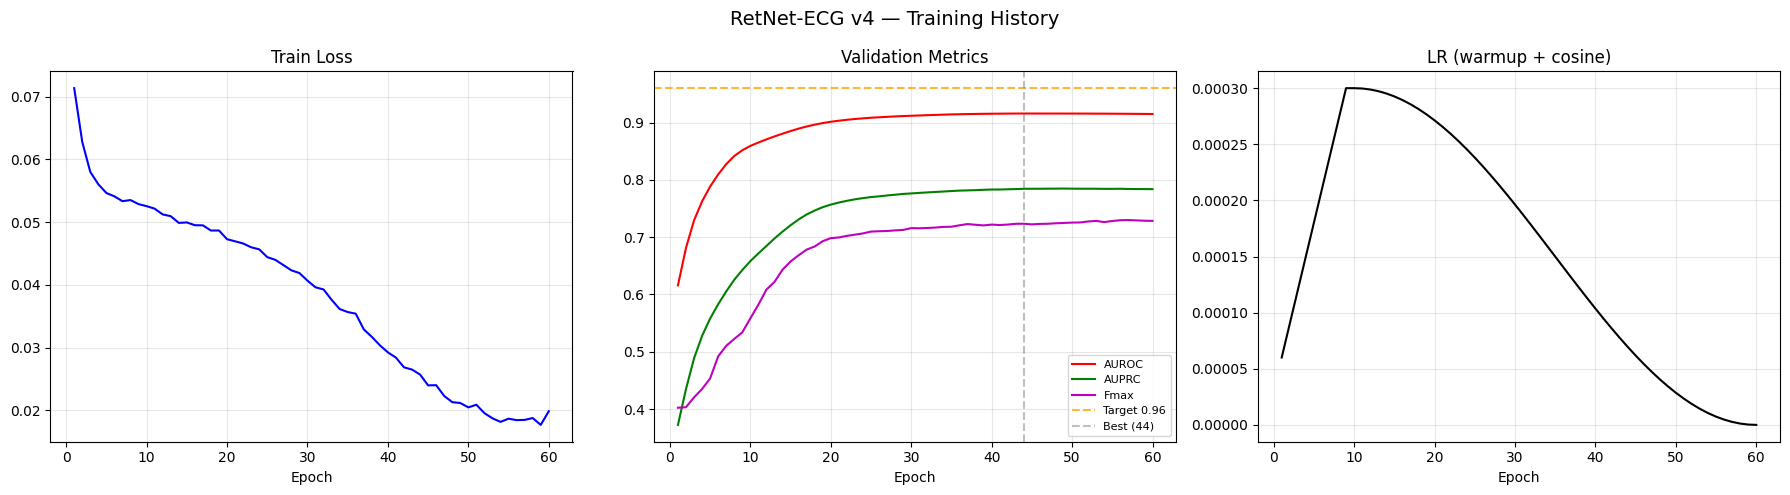


Files saved to /content/drive/MyDrive/train_d/ecg-diploma/results/results_retnet_v4:
  best_model.pt  (536.03 MB)
  metrics.csv  (0.01 MB)
  test_metrics.json  (0.00 MB)
  training_curves.png  (0.13 MB)

>>> Final Macro AUROC = 0.9133
>>> Target 0.96:  ✗ below target


In [10]:
# ── Cell 10: Save Results & Curves ──────────────────────────
import matplotlib.pyplot as plt

with open(out_dir / 'metrics.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=history[0].keys())
    w.writeheader(); w.writerows(history)

with open(out_dir / 'test_metrics.json', 'w') as f:
    json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)

epochs_arr = [h['epoch'] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RetNet-ECG v4 — Training History', fontsize=14)

axes[0].plot(epochs_arr, [h['train_loss']      for h in history], 'b-', lw=1.5)
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_arr, [h['val_macro_auc']   for h in history], 'r-',  lw=1.5, label='AUROC')
axes[1].plot(epochs_arr, [h['val_macro_auprc'] for h in history], 'g-',  lw=1.5, label='AUPRC')
axes[1].plot(epochs_arr, [h['val_fmax']        for h in history], 'm-',  lw=1.5, label='Fmax')
axes[1].axhline(0.96, color='orange', linestyle='--', alpha=0.8, label='Target 0.96')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best ({best_epoch})')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_arr, [h['lr'] for h in history], 'k-', lw=1.5)
axes[2].set_title('LR (warmup + cosine)'); axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / 'training_curves.png', dpi=150)
plt.show()

print(f'\nFiles saved to {out_dir}:')
for fp in sorted(out_dir.iterdir()):
    print(f'  {fp.name}  ({fp.stat().st_size / 1e6:.2f} MB)')

print(f'\n>>> Final Macro AUROC = {test_metrics["macro_auc"]:.4f}')


In [11]:
from sklearn.metrics import roc_auc_score

def predict_simple(model, loader, device):
    """Простое предсказание без TTA — один прогон чистого сигнала."""
    model.eval()
    preds = []
    with torch.no_grad():
        for signals, _ in loader:
            signals = signals.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                preds.append(model(signals).float().sigmoid().cpu())
    return torch.cat(preds).numpy()


print('Loading best EMA model...')
test_model = RetNetECG(
    num_classes=5, d_model=512, n_blocks=10, num_heads=8, drop_path_rate=0.0
)
ckpt = torch.load(out_dir / 'best_model.pt', map_location=device, weights_only=False)
test_model.load_state_dict(ckpt['ema_state_dict'])
test_model = test_model.to(device)

# Истинные метки
labels_list = []
with torch.no_grad():
    for _, labels in test_loader:
        labels_list.append(labels)
y_true_test = torch.cat(labels_list).numpy()

# Один прогон
print('Running single-pass inference...')
y_pred_test  = predict_simple(test_model, test_loader, device)
test_metrics = evaluate(y_true_test, y_pred_test, class_names)

print('\n' + '='*60)
print('TEST RESULTS — RetNet-ECG v4 (EMA, no TTA)')
print('='*60)
print(f'\n  Macro AUROC:  {test_metrics["macro_auc"]:.4f}')
print(f'  Micro AUROC:  {test_metrics["micro_auc"]:.4f}')
print(f'  Macro AUPRC:  {test_metrics["macro_auprc"]:.4f}')
print(f'  Fmax:         {test_metrics["fmax"]:.4f}  (thr={test_metrics["optimal_threshold"]:.3f})')
print(f'  F1 Macro:     {test_metrics["f1_macro"]:.4f}')
print(f'  F1 Micro:     {test_metrics["f1_micro"]:.4f}')
print(f'  Sensitivity:  {test_metrics["sensitivity"]:.4f}')
print(f'  Specificity:  {test_metrics["specificity"]:.4f}')
print(f'  Best epoch:   {ckpt["epoch"]}')
print('='*60)

print('\nPer-class AUROC:')
for i, name in enumerate(class_names):
    if 0 < y_true_test[:, i].sum() < len(y_true_test):
        auc = roc_auc_score(y_true_test[:, i], y_pred_test[:, i])
        print(f'  {name:<6} {auc:.4f}  {bar}')

Loading best EMA model...


/tmp/ipykernel_1944/4250879171.py:208: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Running single-pass inference...

TEST RESULTS — RetNet-ECG v4 (EMA, no TTA)

  Macro AUROC:  0.9132
  Micro AUROC:  0.9311
  Macro AUPRC:  0.7838
  Fmax:         0.7257  (thr=0.575)
  F1 Macro:     0.7069
  F1 Micro:     0.7431
  Sensitivity:  0.8363
  Specificity:  0.8278
  Best epoch:   44

Per-class AUROC:
  NORM   0.9428  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  MI     0.9289  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  STTC   0.9373  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  CD     0.9241  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  HYP    0.8328  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
